In [ ]:
!pip install scikit-learn

In [ ]:
#import libraries

import random
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans

from sklearn import preprocessing
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics
%matplotlib inline

In [ ]:
df = pd.read_csv('kematian_jakarta.csv')
df.head()

,periode_data,wilayah,kecamatan,kelurahan,jenis_kelamin,jumlah,keterangan
0,2023,KOTA ADM. JAKARTA BARAT,GROGOL PETAMBURAN,JELAMBAR,Laki-Laki,130,MATI TAHUN INI
1,2023,KOTA ADM. JAKARTA BARAT,GROGOL PETAMBURAN,TANJUNG DUREN SELATAN,Laki-Laki,87,MATI TAHUN INI
2,2023,KOTA ADM. JAKARTA BARAT,GROGOL PETAMBURAN,JELAMBAR BARU,Laki-Laki,150,MATI TAHUN INI
3,2023,KOTA ADM. JAKARTA BARAT,GROGOL PETAMBURAN,WIJAYA KUSUMA,Laki-Laki,134,MATI TAHUN INI
4,2023,KOTA ADM. JAKARTA BARAT,TAMAN SARI,TAMAN SARI,Laki-Laki,63,MATI TAHUN INI


In [ ]:
df.dtypes

periode_data      int64
wilayah          object
kecamatan        object
kelurahan        object
jenis_kelamin    object
jumlah            int64
keterangan       object
dtype: object

In [ ]:
df['wilayah'].replace(['KOTA ADM. JAKARTA BARAT','KOTA ADM. JAKARTA TIMUR', 'KAB. ADM. KEP. SERIBU',
                       'KOTA ADM. JAKARTA PUSAT', 'KOTA ADM. JAKARTA UTARA', 'KOTA ADM. JAKARTA SELATAN'],[0, 1,2,3,4,5], inplace=True)

In [ ]:
df['jenis_kelamin'].replace(['Laki-Laki','Perempuan'],[0,1], inplace=True)

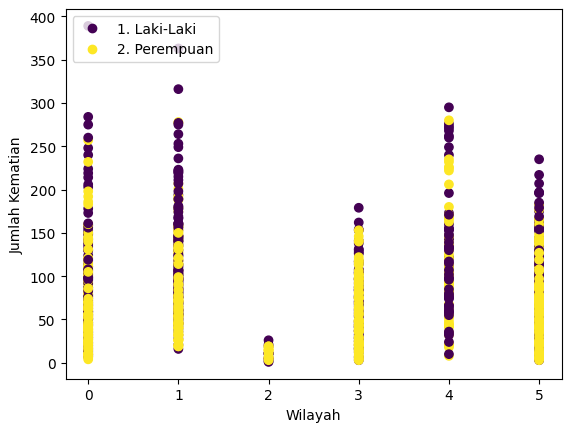

In [ ]:
wilayah = df['wilayah'].values
jumlah = df['jumlah'].values
jenis_kelamin = df['jenis_kelamin'].values

scatter = plt.scatter(wilayah[:,], jumlah[:,], c=jenis_kelamin[:,], cmap='viridis')
cbar = scatter
plt.xlabel('Wilayah')
plt.ylabel('Jumlah Kematian')

plt.legend(handles=scatter.legend_elements()[0], labels=['1. Laki-Laki', '2. Perempuan'], loc='upper left')

plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler
X = df[['wilayah', 'jumlah']].values
X[:10]

array([[  0, 130],
       [  0,  87],
       [  0, 150],
       [  0, 134],
       [  0,  63],
       [  0,  85],
       [  0,  74],
       [  0,  70],
       [  0,  44],
       [  0,  59]])

In [ ]:
X = X.reshape(-1, 1)
X = np.nan_to_num(X)
X = preprocessing.StandardScaler().fit(X).transform(X.astype(float))
X[:10]

array([[-0.8654431],
       [-0.8654431],
       [-0.8654431],
       [-0.8654431],
       [-0.8654431],
       [-0.8654431],
       [-0.8654431],
       [-0.8654431],
       [-0.8654431],
       [-0.8654431]])

In [ ]:
##df['jumlah'] = df['jumlah'].astype(float)

In [ ]:
Y = df['jenis_kelamin'].values
Y = np.nan_to_num(Y)
Y = Y.reshape(-1, 1)
Y[:10]

array([[0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0]])

Split data

In [ ]:
df['jumlah'].isnull().sum()

0

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X,Y, test_size=0.2, random_state=42)
print('data training sebanyak: ', x_train.shape, y_train.shape)
print('data testing sebanyak : ', x_test.shape, y_test.shape)

data training sebanyak:  (854, 2) (854, 1)
data testing sebanyak :  (214, 2) (214, 1)


buat model

fase training

In [ ]:
k = 12
neigh = KNeighborsClassifier(n_neighbors = k).fit(x_train, y_train)
neigh

/usr/local/lib/python3.10/dist-packages/sklearn/neighbors/_classification.py:215: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


KNeighborsClassifier(n_neighbors=12)

fase testing

In [ ]:
yhat = neigh.predict(x_test)
yhat[0:50]

array([1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1,
       0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0,
       0, 1, 1, 0, 1, 0])

cek akurasi

In [ ]:
print("akurasi set train: ", metrics.accuracy_score(y_train, neigh.predict(x_train)))
print("akurasi set test: ", metrics.accuracy_score(y_test, yhat))

akurasi set train:  0.6311475409836066
akurasi set test:  0.4719626168224299
